In [1]:
# import relevant packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
# set figure parameters
sc.settings.set_figure_params(dpi=100)

Advancements in genomics and machine learning have revolutionized both fields and for instance have culminated in models of Virtual Cells, which are trained on high-throughput single-cell genetic screens to learn to predict the effect of genetic perturbations.

With Celcomen we introduce a perturbation model of Virtual Tissues which can be trained on spatial data to learn to predict the effect genetic perturbations in one cell have on itself and its neighboring cells, and validate our model using high-throughput spatial genetic screens

### Data pre-processing

1. Data is downloaded from 10x Genomics (https://www.10xgenomics.com/datasets/xenium-human-brain-preview-data-1-standard, or equivalent)
2. Here, we subset the data for a random region of the tissue (to lower computational costs)
3. Highly variable genes (HVGs) are selected for the "seurat" method (see parameters below)
4. We assign samples accordingly (only one sample in this example), then save the file

In [3]:
# read in xenium
adata = sc.read_10x_h5('../../LITERATURE/XENIUM_HUMAN_GBM/cell_feature_matrix.h5')
adata.var_names = adata.var_names.astype(str)
adata.var_names_make_unique()
# remove cells with no counts
sc.pp.filter_cells(adata, min_counts=100)
# normalize the data
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.log1p(adata)

# read in the spatial
df = pd.read_csv('../../LITERATURE/XENIUM_HUMAN_GBM/cells.csv.gz', index_col=0)
df = df.loc[adata.obs.index]
# add spatial and subset
adata.obsm['spatial'] = df.loc[adata.obs.index, ['x_centroid','y_centroid']].values
mask = (df['x_centroid'] < 7000) & (df['x_centroid'] > 6700)
mask = mask & (df['y_centroid'] < 8300) & (df['y_centroid'] > 8000)
adata = adata[mask].copy()

# compute PCA for the spatial dataset using HVGs
adata.uns['log1p']['base'] = np.e
sc.pp.highly_variable_genes(adata, flavor='seurat', min_mean=0.5, max_mean=7.5, min_disp=0.5, n_top_genes=adata.shape[1])
# report how many HVGs we're going to use
print('There are', adata.var['highly_variable'].sum(), 'HVGs')

# subset for relevant hvgs
hvgs = adata.var.index[adata.var['highly_variable']]
adata = adata[:, hvgs].copy()
adata.obs['sample'] = '0'
# write the data
adata.write('expr.h5ad')

/home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:251: UserWarning: If you pass `n_top_genes`, all cutoffs are ignored.
  warnings.warn(msg, UserWarning)


There are 451 HVGs


/home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:412: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(msg, UserWarning)


### Celcomen Training

5. The saved H5AD file frm above is read into Celcomen's dataloader (the device can be "cuda" or "cpu")
6. Based on the spatial transcriptomics datatype (e.g. subcellular vs spot-resoltuin), one can choose to use k-nearest-neighbors (k parameter) or a set distance (distance parameter, units derived from the .spatial attribute of the AnnData object) to find edges
7. Celcomen model is then formally run with the parameters below (example loss is depicted)

In [4]:
from celcomen.datareaders.datareader import get_dataset_loaders

# define dataloader parameters
sample = 'sample'
k = 6
distance = 15
device = 'cuda'
verbose = False
# derive dataloader using knn graph
dataloader = get_dataset_loaders('expr.h5ad', sample_id_name=sample,
                                 n_neighbors=k, distance=distance, device=device, verbose=verbose)

/home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/torch_geometric/typing.py:54: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib/x86_64-linux-gnu/libm.so.6: version `GLIBC_2.29' not found (required by /home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/torch_geometric/typing.py:72: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKSs
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/dchen2/anaconda3/envs/gpu39/lib/python3.9/site-packages/torch_geometric/typing.py:99: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace:

In [5]:
from celcomen.models.celcomen import celcomen
from celcomen.utils.helpers import *
from celcomen.training_plan.train import train

# define celcomen model parameters
n = len(hvgs)
lr = 1e-1
zmft = 1e-1
seed = 0
epochs = 200
# generate celcomen model
model = celcomen(input_dim=n, output_dim=n, n_neighbors=k, seed=seed)
# normalize model inputs
input_g2g = np.random.uniform(size=(n, n)).astype('float32')
input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
model.set_g2g(torch.from_numpy(input_g2g))
model.set_g2g_intra(torch.from_numpy(input_g2g))
model.to(device)
# train model
losses = train(epochs, lr, model, dataloader, zmft_scalar=zmft, seed=seed, device=device)

100%|████████████████████████████████████████| 200/200 [00:07<00:00, 28.53it/s]


(-43.760888671875, 4419.849755859375)

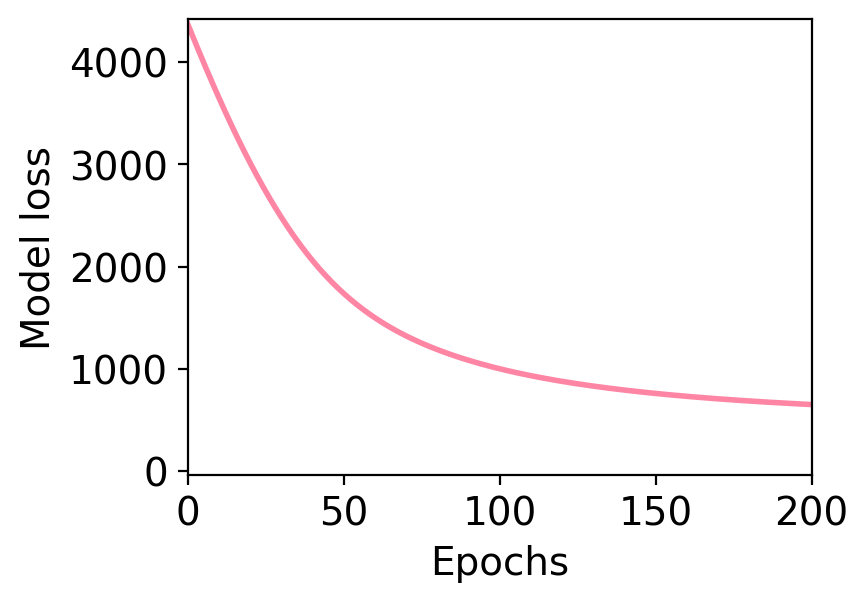

In [6]:
# plot the loss curve
fig, ax = plt.subplots(figsize=[4, 3])
ax.grid(False)
ax.plot(losses, lw=2, color='#fe86a4')
ax.set_xlim(0, epochs)
ax.set(xlabel='Epochs', ylabel='Model loss')
# adjust the y-axis to be relevant
vmin, vmax = min(min(losses), 0), max(losses)
vstep = (vmax - vmin) * 0.01
ax.set_ylim(vmin - vstep, vmax + vstep)

### Simcomen Training

8. Original data ("orig_data") is saved separately prior to perturbation ("IFITM3" knockout, perturbed observation is randomly chosen)
9. Celcomen's learned parameters are transmitted to Simcomen prior to Simcomen's training on the perturbed data
10. Predicted change in expression is derived as the difference between post- and pre-Simcomen training data
11. Gene set enrichment analysis of said change in expression was completed on all differential genes (Z<-1) except for IFITM3 which, by definition, is downregulated and therefore must be excluded to solely examine model predicted changes
12. Comparison of IFN-signaling downregulation in proximal and distal neighbors of the perturbed spot

In [32]:
# # propose a new expression matrix
# orig_data = adata.copy()
# prop_expr = adata.X.toarray().copy()
# np.random.seed(0)
# expr = sc.get.obs_df(adata, keys='IFITM3')
# # adjust gene proposed to be perturbed
# mask = adata.obs.index == np.random.choice(adata.obs.index[expr > 0], size=1)[0]
# gene_idx = np.where(adata.var_names == 'IFITM3')[0][0]
# prop_expr[mask, gene_idx] = 0
# adata.X = prop_expr
# adjust perturbation in the .obs attribute
adata.obs['perturbed'] = 'unperturbed'
adata.obs.loc[mask, 'perturbed'] = 'perturbed'
# call for neighbors to the perturbed spot
from scipy.spatial.distance import cdist
coords = adata.obsm['spatial']
mask = adata.obs['perturbed'] == 'perturbed'
dist = pd.Series(cdist(coords[mask.values, :], coords)[0, :], index=adata.obs.index)
adata.obs.loc[(dist > 0) & (dist < 30), 'perturbed'] = 'neighbors'

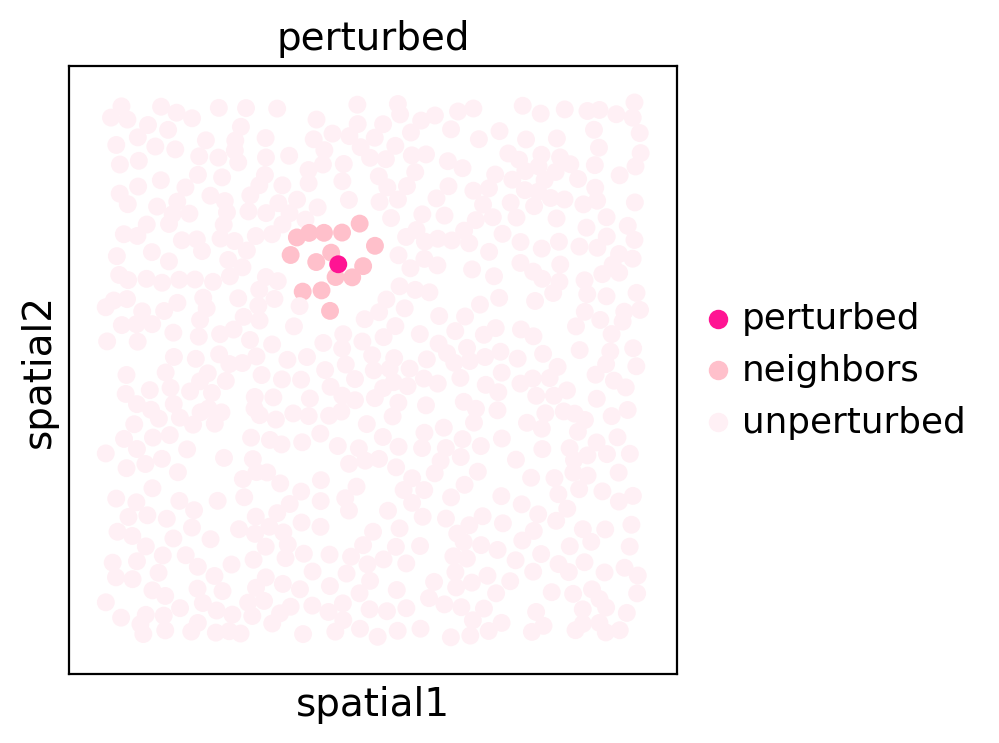

In [33]:
# visualize the perturbation spatially
adata.obs['perturbed'] = pd.Categorical(adata.obs['perturbed'], categories=['perturbed','neighbors','unperturbed'])
adata.uns['perturbed_colors'] = ['deeppink','pink','lavenderblush']
sc.pl.spatial(adata, color=['perturbed'], spot_size=10)

In [34]:
# define the parameters of the model
lr = 1e-3
momentum = 0
zmft = 1e-1
seed = 0
epochs = 50

In [35]:
from sklearn.neighbors import kneighbors_graph
from celcomen.models.simcomen import simcomen
from tqdm import tqdm

# derive the original expression
expr = torch.from_numpy(adata[:, hvgs].X)
norm_factor = torch.sqrt(torch.pow(expr, 2).sum(1)).reshape(-1,1)
assert (norm_factor > 0).all()
base_expr = torch.div(expr, norm_factor)

# identify spatial edges
pos = torch.from_numpy(adata.obsm['spatial'])
edges = kneighbors_graph(pos, k, include_self=False).todense()
edges = torch.from_numpy(np.array(np.where(edges))).to(device)
# prepare expression
np.random.seed(seed)
expr = torch.from_numpy(adata.X)
norm_factor = torch.sqrt(torch.pow(expr, 2).sum(1)).reshape(-1,1)
assert (norm_factor > 0).all()
expr = torch.div(expr, norm_factor).to(device)

# create simcomen model
model_sim = simcomen(input_dim=n, output_dim=n, n_neighbors=k, seed=seed)
model_sim.set_g2g(model.conv1.lin.weight.clone().detach())
model_sim.set_g2g_intra(model.lin.weight.clone().detach())
input_sphex = calc_sphex(expr).clone().detach().numpy()
model_sim.set_sphex(torch.from_numpy(input_sphex.astype('float32')))
model_sim.to(device)

# train the model
optimizer = torch.optim.SGD(model_sim.parameters(), lr=lr, momentum=momentum)
model_sim.train()
for epoch in tqdm(range(epochs), total=epochs):
    # derive the message and the mean field approximation
    msg, msg_intra, log_z_mft = model_sim(edges, 1)
    if epoch == 0:
        if device == 'cuda': orig_expr = model_sim.gex.clone().detach().cpu().numpy()
        elif device == 'cpu': orig_expr = model_sim.gex.clone().detach().numpy()
    # compute the loss
    loss = -(-log_z_mft + zmft * torch.trace(torch.mm(msg, torch.t(model_sim.gex))) + \
             zmft * torch.trace(torch.mm(msg_intra, torch.t(model_sim.gex))))
    # derive the gradients, update, and clear
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
if device == 'cuda': pred_expr = model_sim.gex.detach().cpu().numpy()
elif device == 'cpu': pred_expr = model_sim.gex.detach().numpy()
adata.layers['expr_diff'] = pred_expr - orig_expr

100%|██████████████████████████████████████████| 50/50 [25:05<00:00, 30.12s/it]


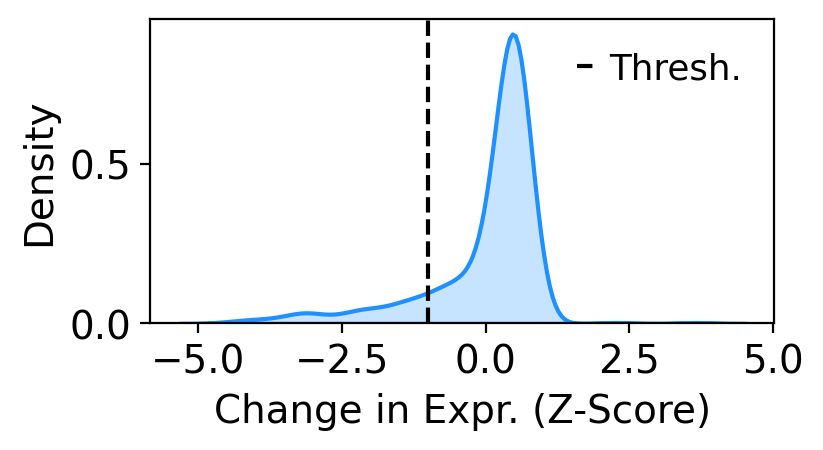

In [37]:
import seaborn as sns
# identify gene expression differences
expr = pd.DataFrame(adata.layers['expr_diff'], columns=adata.var.index).mean(0).sort_values()
expr -= expr.mean(); expr /= expr.std()
fig, ax = plt.subplots(figsize=[4, 2])
_ = ax.grid(False)
sns.kdeplot(expr, lw=1.5, fill=True, color='dodgerblue')
_ = ax.axvline(-1, linestyle='--', lw=1.5, color='k', label='Thresh.')
_ = ax.legend(frameon=False)
_ = ax.set(xlabel='Change in Expr. (Z-Score)')

In [38]:
import gseapy as gp
# retrieve gene list of interest
gene_list = expr.index[expr < -1].tolist()
# remove ifitm3 to avoid contamination
gene_list = [el for el in gene_list if el != 'IFITM3']

# query against enrichr with GO:BP keeping only p<0.05
gene_sets = ['GO_Biological_Process_2025']
enr_results = gp.enrichr(
    gene_list=gene_list,
    gene_sets=gene_sets,
    organism='hs',
    cutoff=0.05
)
results_df = enr_results.results

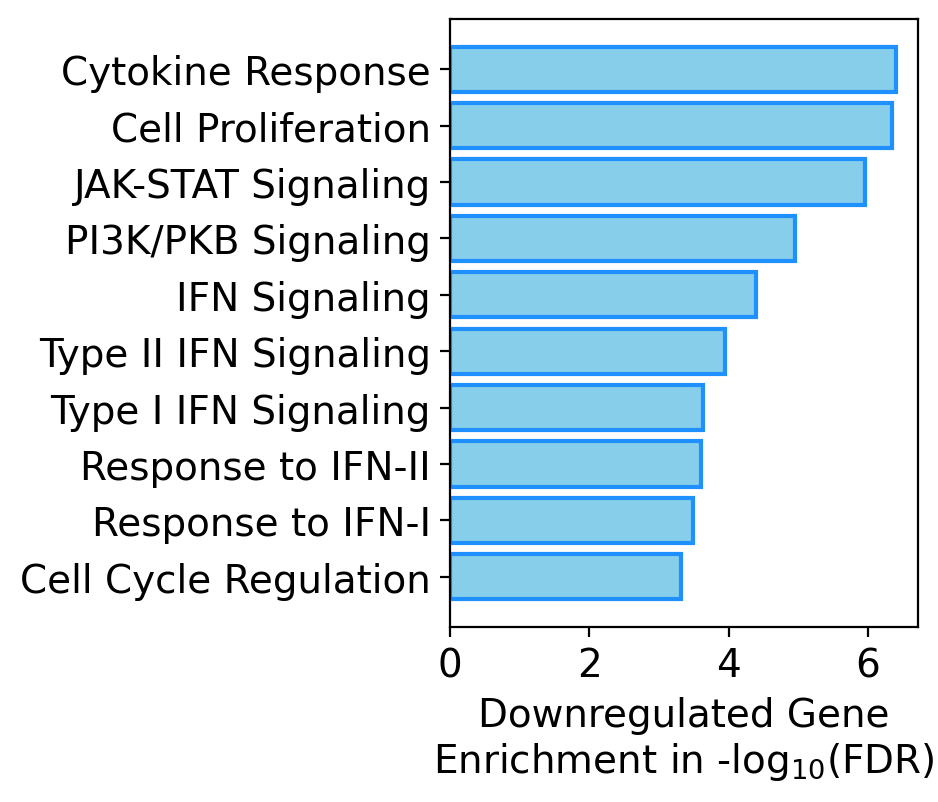

In [39]:
# highlight relevant gene programs
paths = '''Cellular Response to Cytokine Stimulus (GO:0071345)
Positive Regulation of Cell Population Proliferation (GO:0008284)
Cell Surface Receptor Signaling Pathway via JAK-STAT (GO:0007259)
Phosphatidylinositol 3-Kinase/Protein Kinase B Signal Transduction (GO:0043491)
Interferon-Mediated Signaling Pathway (GO:0140888)
Type II Interferon-Mediated Signaling Pathway (GO:0060333)
Type I Interferon-Mediated Signaling Pathway (GO:0060337)
Cellular Response to Type I Interferon (GO:0071357)
Cellular Response to Type II Interferon (GO:0071346)
Regulation of G1/S Transition of Mitotic Cell Cycle (GO:2000045)'''.split('\n')
labels = ['Cytokine Response','Cell Proliferation','JAK-STAT Signaling','PI3K/PKB Signaling',
          'IFN Signaling','Type II IFN Signaling','Type I IFN Signaling','Response to IFN-II',
          'Response to IFN-I','Cell Cycle Regulation']
# plot the programs on a bar plot
fig, ax = plt.subplots(figsize=[3, 4])
_ = ax.grid(False)
data = results_df[['Term','Adjusted P-value']].copy()
data = data.set_index('Term').loc[paths]
data.index = labels
fdrs = -np.log10(data['Adjusted P-value'])[::-1]
_ = ax.barh(fdrs.index, fdrs, edgecolor='dodgerblue', lw=1.5, color='skyblue')
_ = ax.set(xlabel='Downregulated Gene\nEnrichment in -log$_{10}$(FDR)')

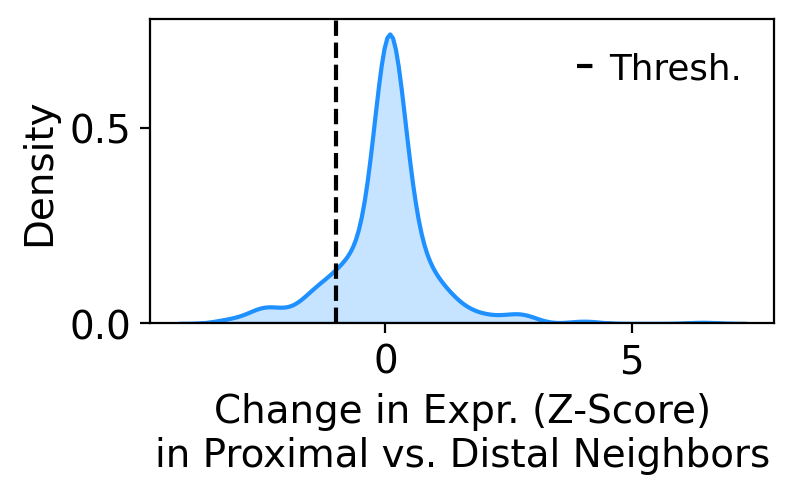

In [41]:
# identify gene expression differences in proximal vs. distal neighbors
mask_nbrs = adata.obs['perturbed'] == 'neighbors'
expr_nbrs = pd.DataFrame(adata[mask_nbrs].layers['expr_diff'], columns=adata.var.index).mean(0)
mask_unpt = adata.obs['perturbed'] == 'unperturbed'
expr_unpt = pd.DataFrame(adata[mask_unpt].layers['expr_diff'], columns=adata.var.index).mean(0)
expr = (expr_nbrs - expr_unpt).sort_values()
expr -= expr.mean(); expr /= expr.std()
fig, ax = plt.subplots(figsize=[4, 2])
_ = ax.grid(False)
sns.kdeplot(expr, lw=1.5, fill=True, color='dodgerblue')
_ = ax.axvline(-1, linestyle='--', lw=1.5, color='k', label='Thresh.')
_ = ax.legend(frameon=False)
_ = ax.set(xlabel='Change in Expr. (Z-Score)\nin Proximal vs. Distal Neighbors')

In [42]:
import gseapy as gp
# retrieve gene list of interest
gene_list = expr.index[expr < -1].tolist()
# remove ifitm3 to avoid contamination
gene_list = [el for el in gene_list if el != 'IFITM3']

# query against enrichr with GO:BP keeping only p<0.05
gene_sets = ['GO_Biological_Process_2025']
enr_results = gp.enrichr(
    gene_list=gene_list,
    gene_sets=gene_sets,
    organism='hs',
    cutoff=0.05
)
results_df = enr_results.results

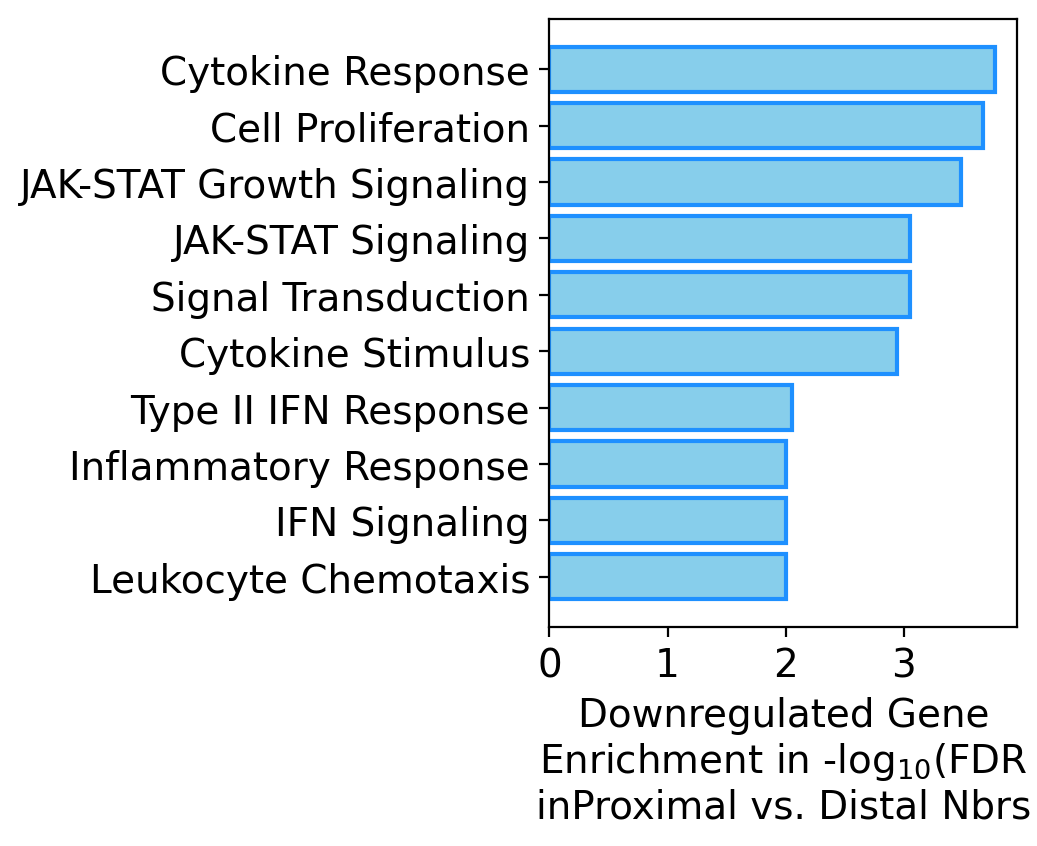

In [48]:
# highlight relevant gene programs
paths = '''Cytokine-Mediated Signaling Pathway (GO:0019221)
Regulation of Cell Population Proliferation (GO:0042127)
Growth Hormone Receptor Signaling Pathway via JAK-STAT (GO:0060397)
Cell Surface Receptor Signaling Pathway via JAK-STAT (GO:0007259)
Positive Regulation of Intracellular Signal Transduction (GO:1902533)
Cellular Response to Cytokine Stimulus (GO:0071345)
Cellular Response to Type II Interferon (GO:0071346)
Regulation of Cytokine Production Involved in Inflammatory Response (GO:1900015)
Interferon-Mediated Signaling Pathway (GO:0140888)
Positive Regulation of Leukocyte Chemotaxis (GO:0002690)'''.split('\n')
labels = ['Cytokine Response','Cell Proliferation','JAK-STAT Growth Signaling','JAK-STAT Signaling',
          'Signal Transduction','Cytokine Stimulus','Type II IFN Response','Inflammatory Response',
          'IFN Signaling','Leukocyte Chemotaxis']
# plot the programs on a bar plot
fig, ax = plt.subplots(figsize=[3, 4])
_ = ax.grid(False)
data = results_df[['Term','Adjusted P-value']].copy()
data = data.set_index('Term').loc[paths]
data.index = labels
fdrs = -np.log10(data['Adjusted P-value'])[::-1]
_ = ax.barh(fdrs.index, fdrs, edgecolor='dodgerblue', lw=1.5, color='skyblue')
_ = ax.set(xlabel='Downregulated Gene\nEnrichment in -log$_{10}$(FDR\ninProximal vs. Distal Nbrs')

In [49]:
print()